# Sleep Quality Prediction

### Sleep Quality Analysis
The Sleep Health and Lifestyle Dataset contains 374 rows and 13 columns, providing insights into various factors affecting sleep and daily lifestyle habits. It includes information on demographics, sleep metrics, lifestyle factors, cardiovascular health, and sleep disorders. The dataset covers key variables such as age, gender, occupation, sleep duration, quality of sleep, physical activity, stress levels, BMI, blood pressure, heart rate, daily steps, and sleep disorders like insomnia and sleep apnea.

In [94]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings('ignore')

 ## Data Overview & Cleaning

- Person ID: An identifier for each individual.
- Gender: The gender of the person (Male/Female).
- Age: The age of the person in years.
- Occupation: The occupation or profession of the person.
- Sleep Duration (hours): The number of hours the person sleeps per day.
- Quality of Sleep (scale: 1-10): A subjective rating of the quality of sleep, ranging from 1 to 10.
- Physical Activity Level (minutes/day): The number of minutes the person engages in physical activity daily.
- Stress Level (scale: 1-10): A subjective rating of the stress level experienced by the person, ranging from 1 to 10.
- BMI Category: The BMI category of the person (e.g., Underweight, Normal, Overweight).
- Blood Pressure (systolic/diastolic): The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure.
- Heart Rate (bpm): The resting heart rate of the person in beats per minute.
- Daily Steps: The number of steps the person takes per day.
- Sleep Disorder: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea).

In [95]:
# Read data
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [96]:
# Check data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [97]:
# Check basic data summary for textual variables
df.describe(include='O')

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


In [98]:
# Check basic data summary for numeric variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Person ID,374.0,187.500000,108.108742,1.0,94.25,187.5,280.75,374.0
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.00,59.0
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.80,8.5
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.00,9.0
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.00,90.0
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.00,8.0
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.00,86.0
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.00,10000.0


In [99]:
# Check for missing values in the dataset and print only those columns with at least one missing value
missing = df.isnull().sum()
print(missing[missing > 0])

Sleep Disorder    219
dtype: int64


In [100]:
# Remove redundant column 'Person ID'
if 'Person ID' in df.columns:
    df.drop(columns=['Person ID'], inplace=True)

# Extract Systolic and Diastolic Blood Pressure before dropping original column
df['Systolic BP'] = df['Blood Pressure'].str.split('/').str[0].astype(int)
df['Diastolic BP'] = df['Blood Pressure'].str.split('/').str[1].astype(int)

# Now drop the original 'Blood Pressure' column
df.drop("Blood Pressure", axis=1, inplace=True)

In [101]:
# Transform BMI column
df['BMI Category'] = df['BMI Category'].replace("Normal Weight", "Normal")

In [102]:
# Check number of numerical columns, textual columns, categorical columns, and discrete columns.
num_cols = [i for i in df.columns if df[i].dtype in ['int64', 'float64']]
text_cols = [i for i in df.columns if df[i].dtype =='object']
cat_cols = [i for i in df.columns if len(df[i].unique()) <= 10]
disc_cols = [i for i in df.columns if len(df[i].unique()) > 10]
print("Numerical Columns: ", num_cols)
print("Textual Columns: ", text_cols)
print("Categorical Columns: ", cat_cols)
print("Discrete Columns: ", disc_cols)

Numerical Columns:  ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']
Textual Columns:  ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
Categorical Columns:  ['Gender', 'Quality of Sleep', 'Stress Level', 'BMI Category', 'Sleep Disorder']
Discrete Columns:  ['Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']


In [103]:
# Check null values
df.isna().sum()

,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Heart Rate,0
Daily Steps,0


In [104]:
# In Sleep Disorder column, 219 Nan are present, we cannot drop it since there are only 374 rows. We will replace it by "No Disease".
df['Sleep Disorder'].fillna('No Disease', inplace=True)

In [105]:
# Check null values again
df.isna().sum()

,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Heart Rate,0
Daily Steps,0


## Univariate Analysis

In [106]:
# Utility Functions
def univariate_analysis(cat_cols, disc_cols):
    """
    Perform univariate analysis for categorical and discrete columns.
    For categorical columns, it generates count plots to show the frequency of each category.
    For discrete columns, it generates histograms with KDE (Kernel Density Estimate).

    Parameters:
    ----------
    cat_cols : list
        A list of categorical column names to analyze and visualize.
    disc_cols : list
        A list of discrete column names to analyze and visualize.

    Returns:
    -------
    None
        The function generates visualizations for the provided column types and displays them.
    """
    # For categorical columns
    for col in cat_cols:
        plt.figure(figsize=(10, 8))
        sns.countplot(data=df, x=col, palette='Set2', order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
        print()

    # For discrete columns
    for col in disc_cols:
        plt.figure(figsize=(10, 8))
        sns.histplot(df[col], kde=True, bins=30, color='green')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.xticks(rotation=45)
        plt.show()
        print()

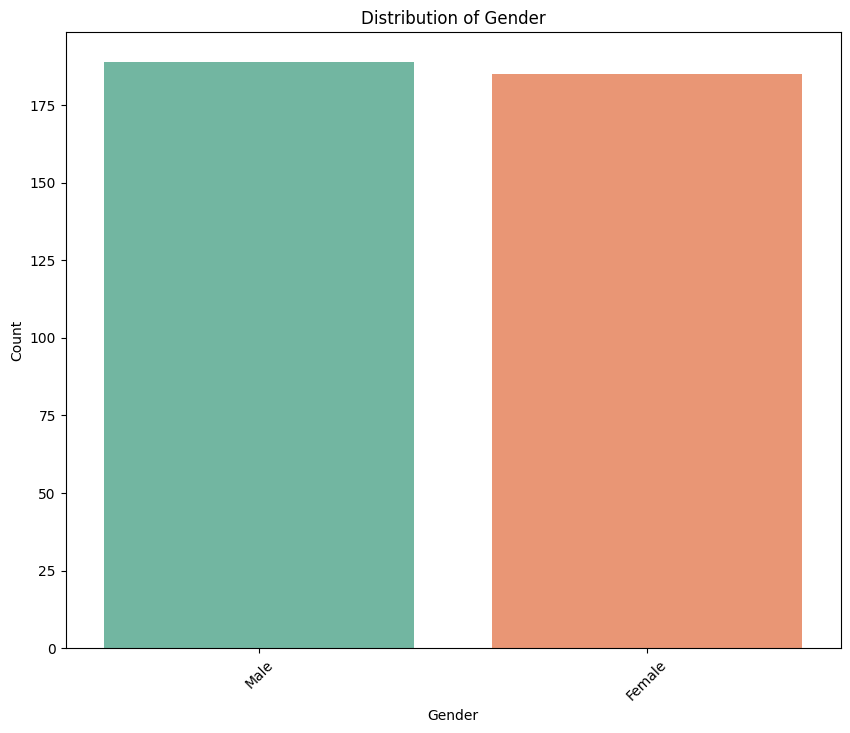

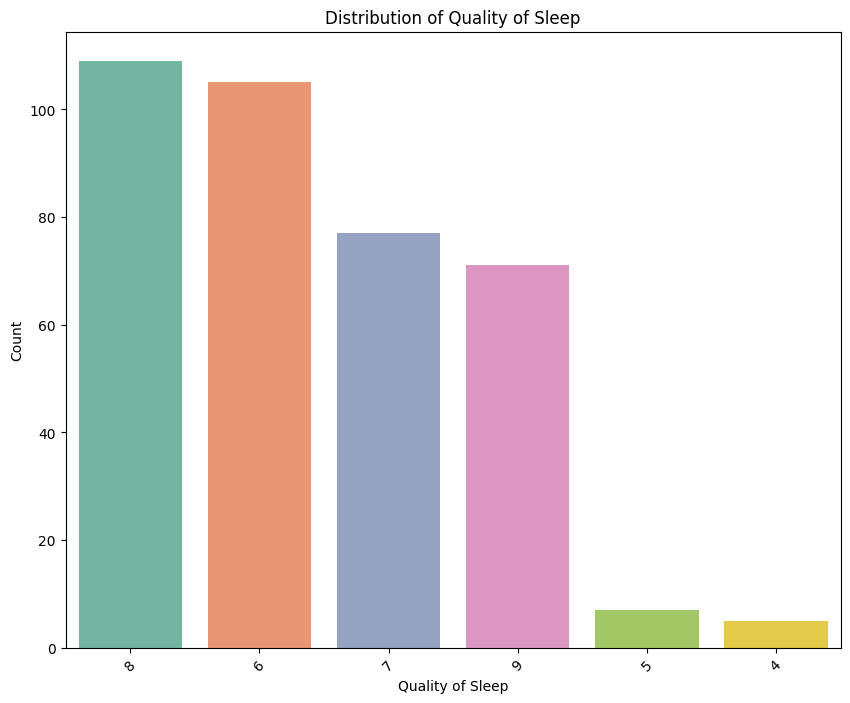

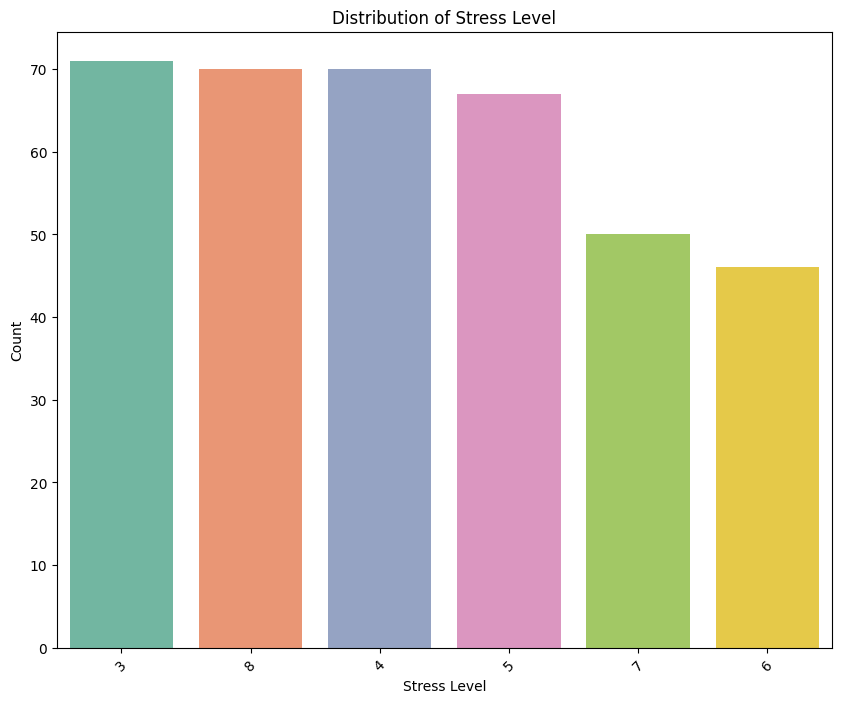

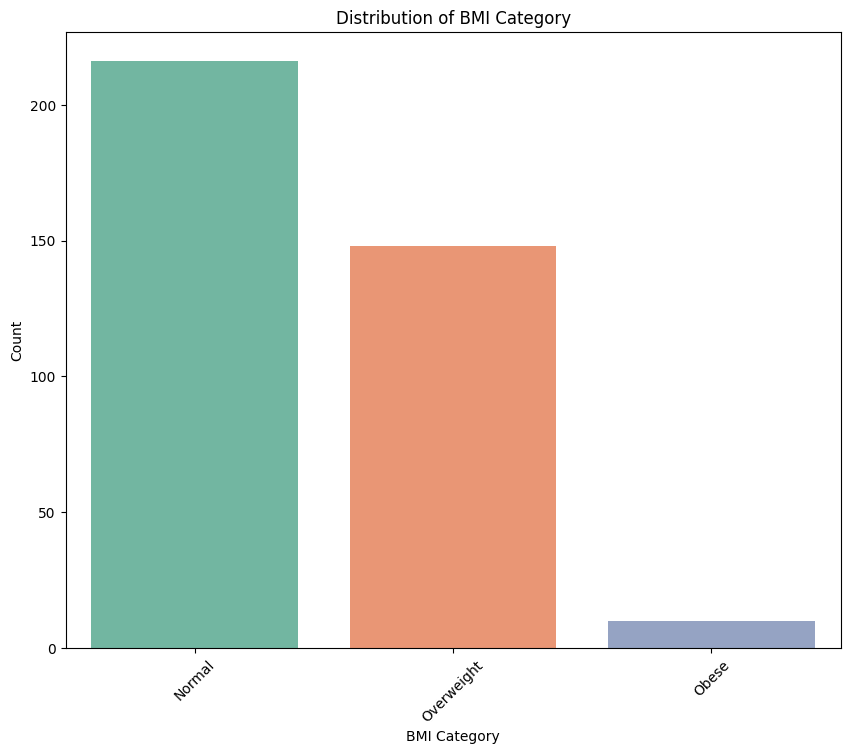

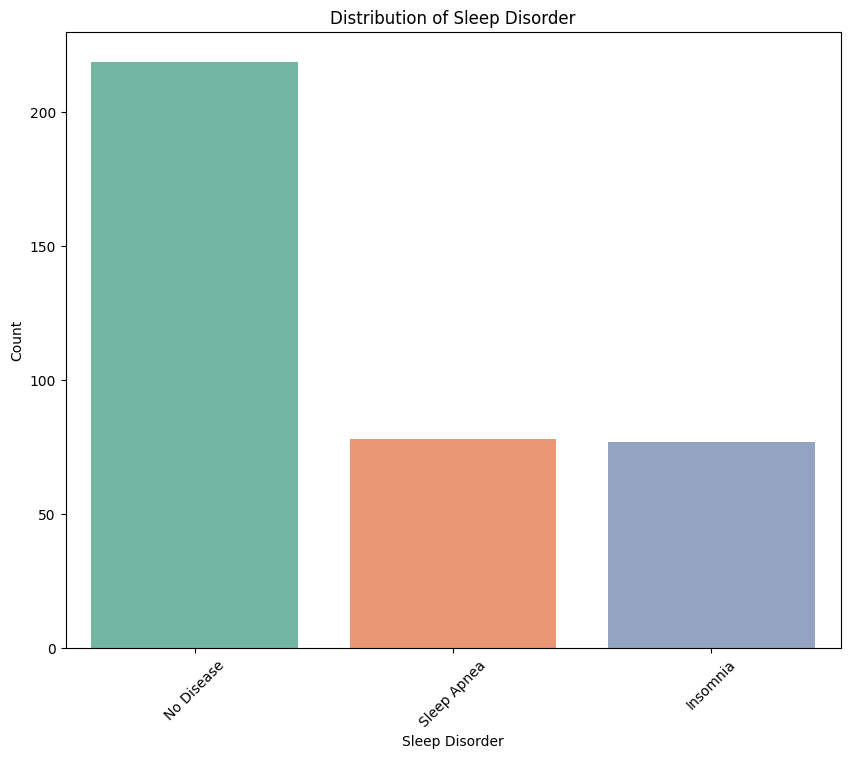

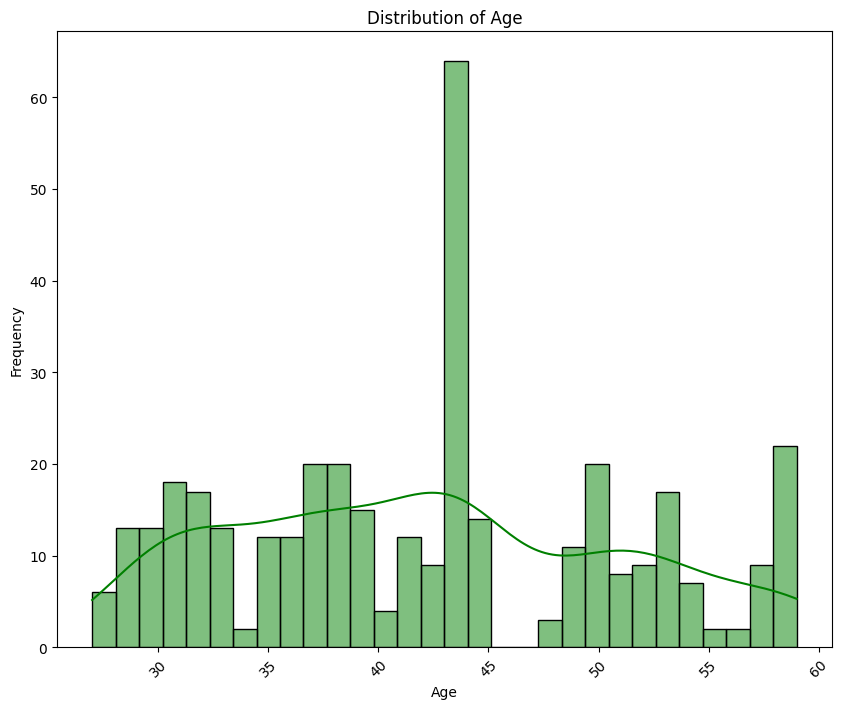

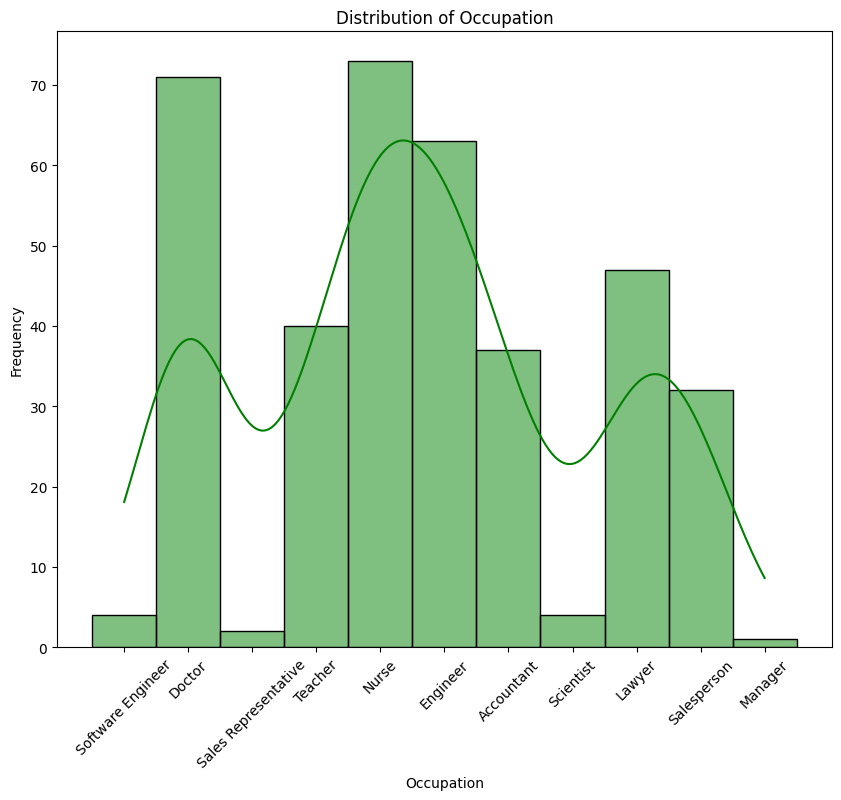

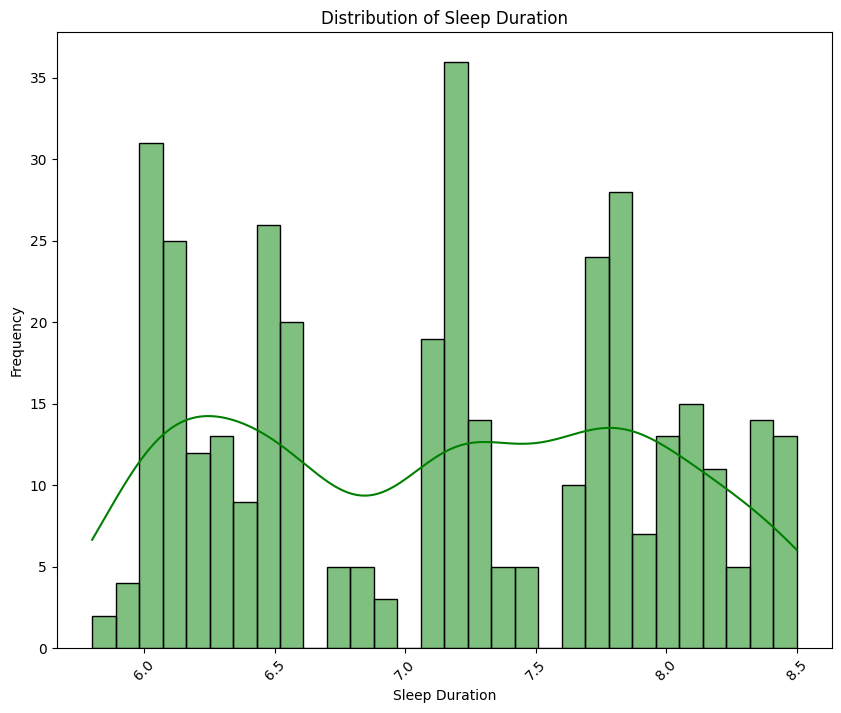

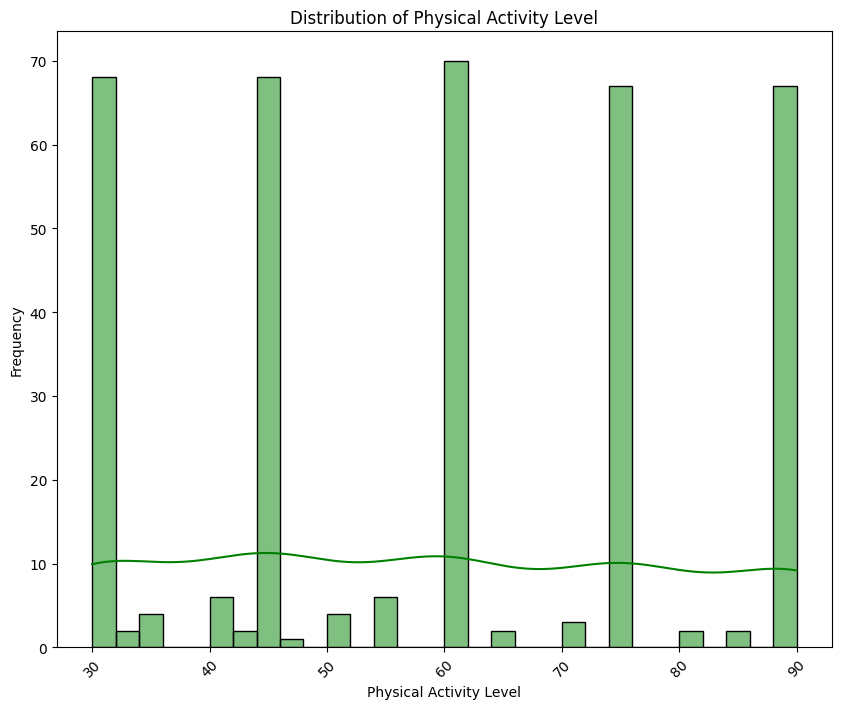

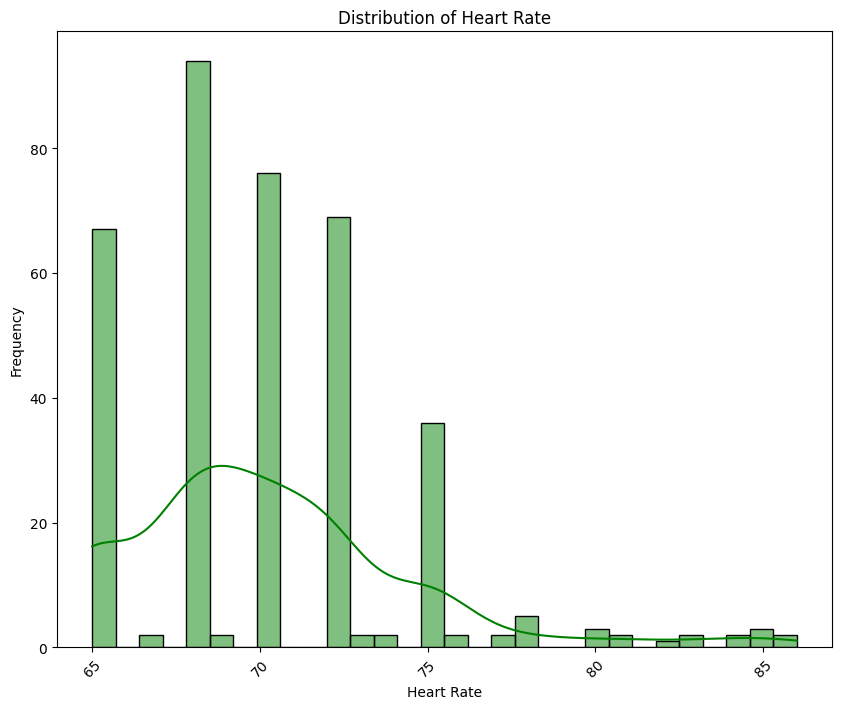

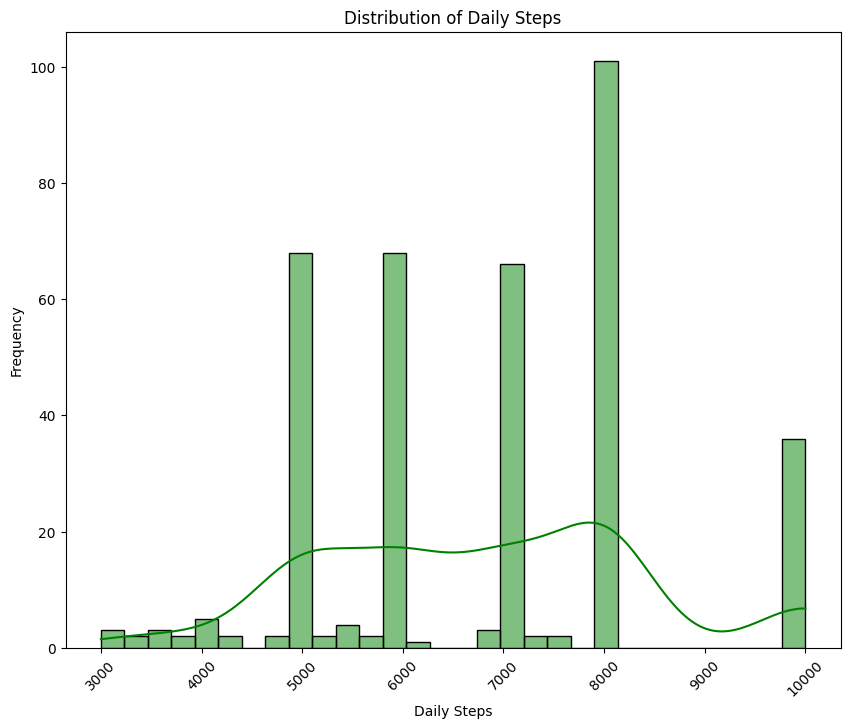

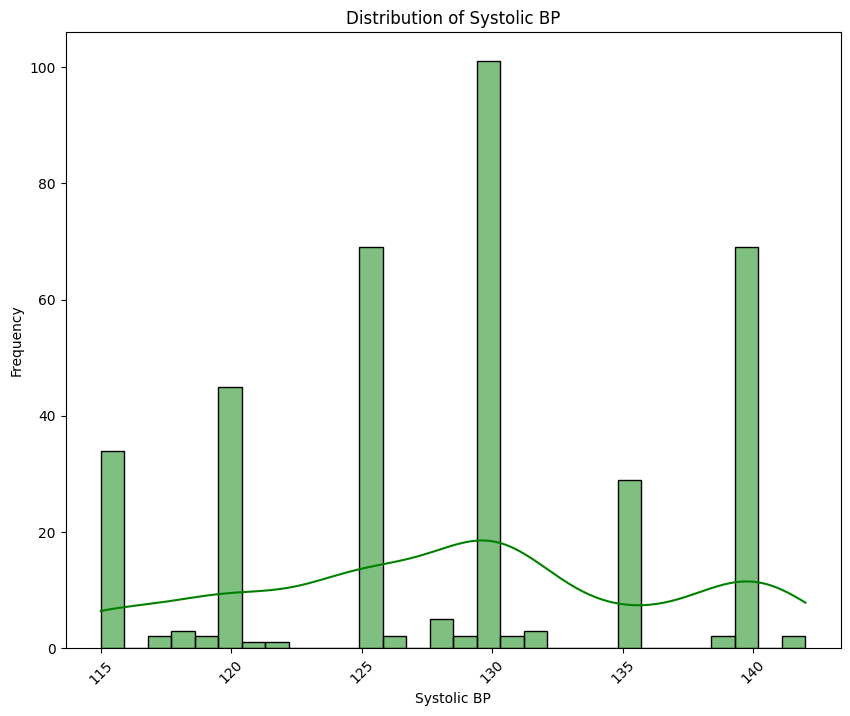

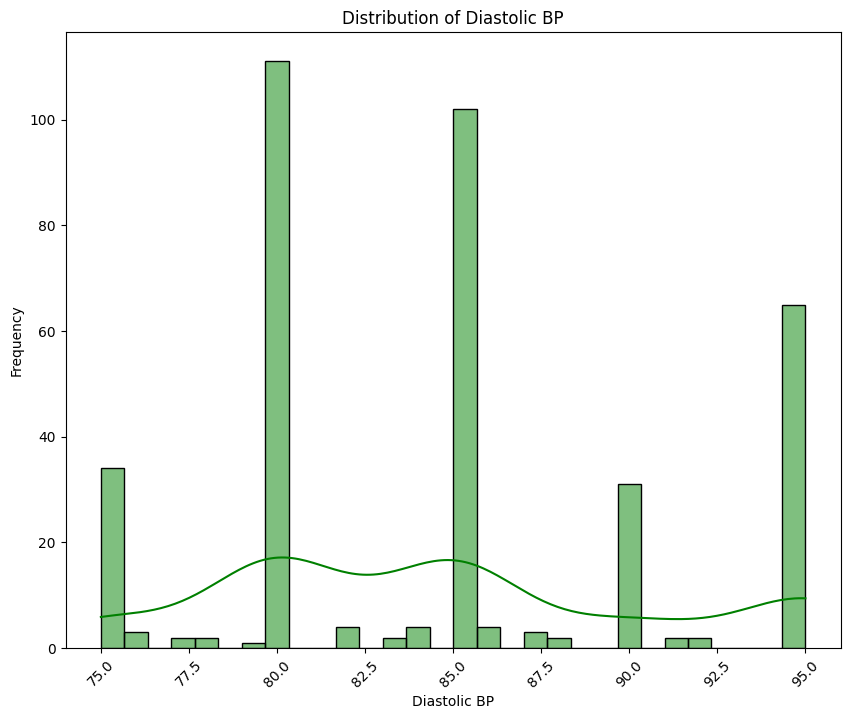

In [107]:
# Univariate Analysis
univariate_analysis(cat_cols, disc_cols)

##  Multivariate Analysis

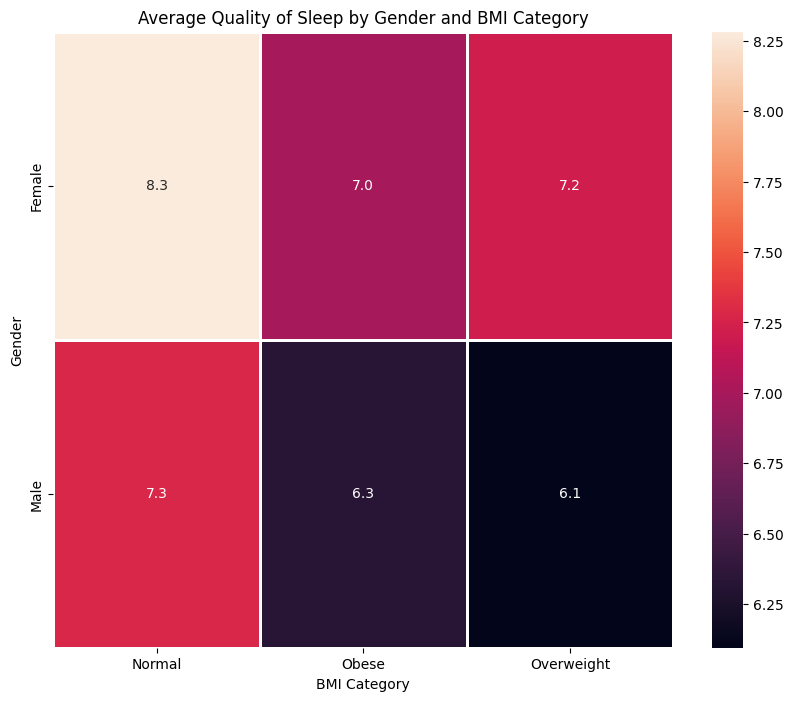

In [108]:
# Multivariate analysis
# Q: Does sleep quality vary by gender and BMI category?
plt.figure(figsize=(10, 8))
heatmap = df.pivot_table(values='Quality of Sleep', index='Gender', columns='BMI Category', aggfunc='mean')
sns.heatmap(heatmap, annot=True, fmt=".1f", linewidth=1)
plt.title("Average Quality of Sleep by Gender and BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Gender")
plt.show()

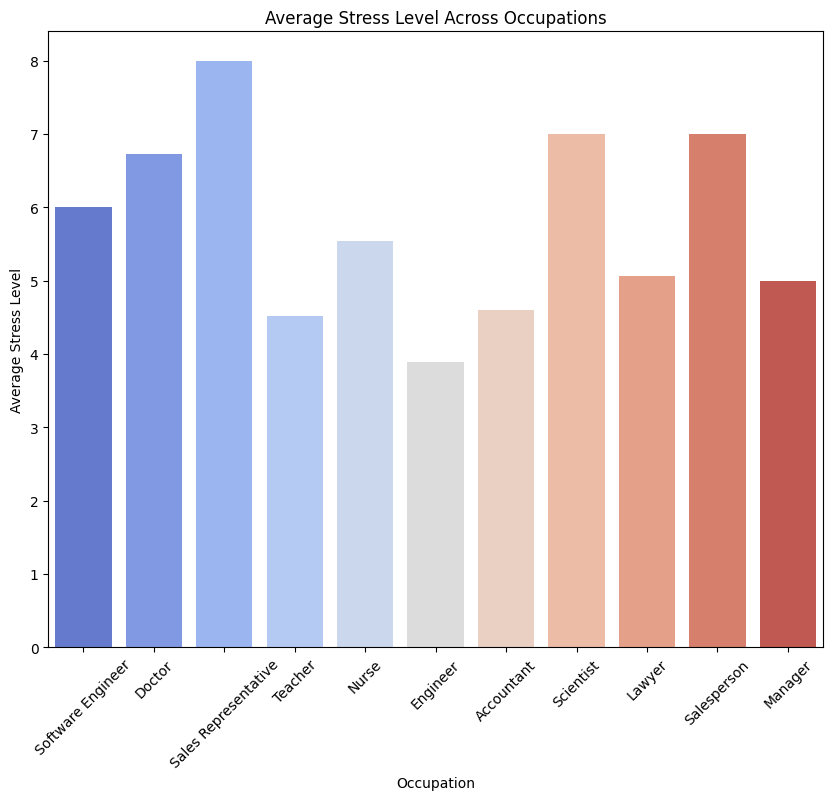

In [109]:
# Q: Which occupations experience the highest stress levels?
plt.figure(figsize=(10, 8))
sns.barplot(data=df, x="Occupation", y="Stress Level", palette="coolwarm", ci=None)
plt.title("Average Stress Level Across Occupations")
plt.xlabel("Occupation")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=45)
plt.show()

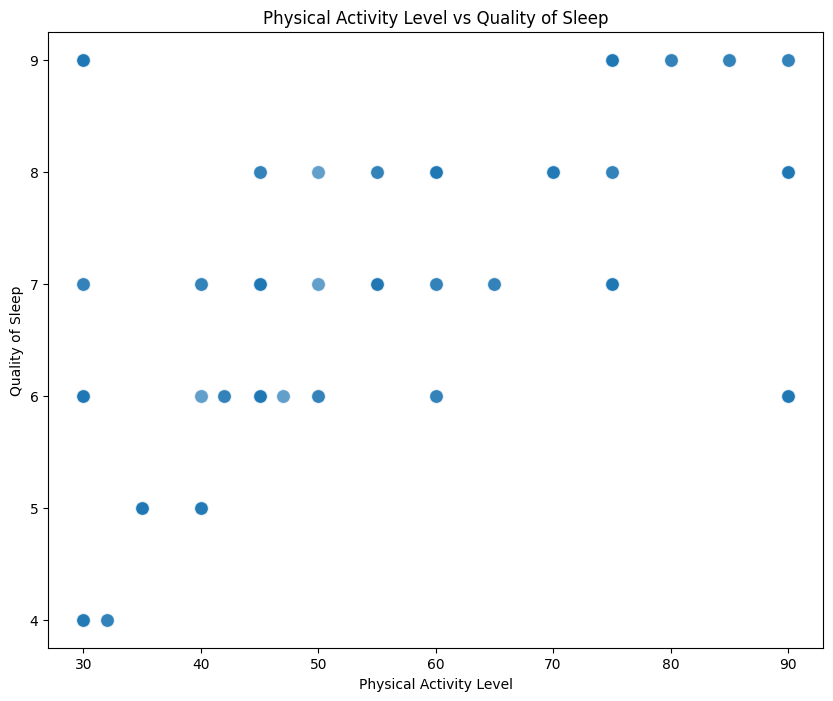

In [110]:
# Q: Does physical activity level affect the quality of sleep?
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x="Physical Activity Level", y="Quality of Sleep", s=100, alpha=0.7)
plt.title("Physical Activity Level vs Quality of Sleep")
plt.xlabel("Physical Activity Level")
plt.ylabel("Quality of Sleep")
plt.show()

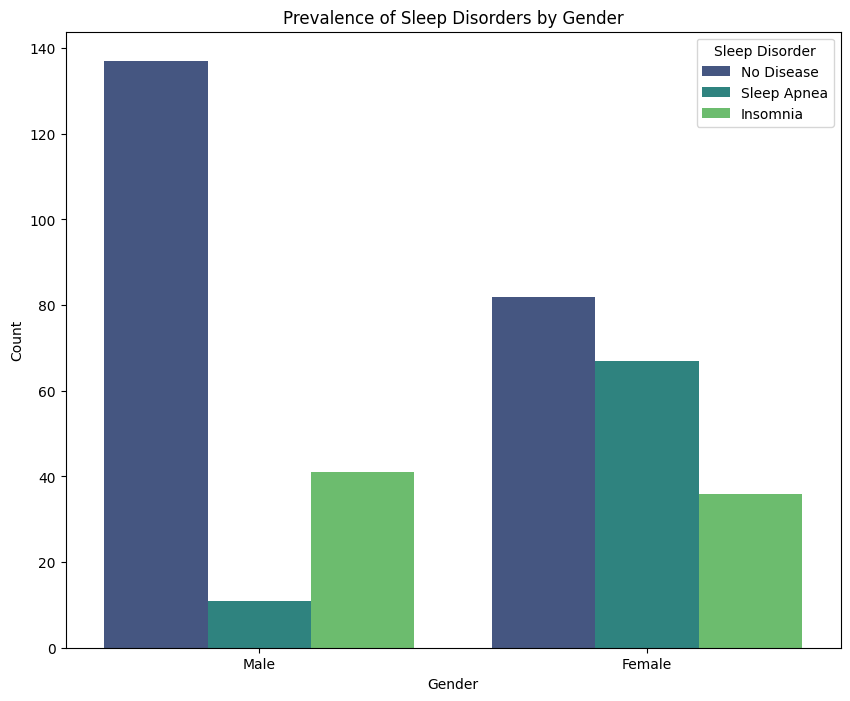

In [111]:
# Q: How does the prevalence of sleep disorders differ between genders?
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x="Gender", hue="Sleep Disorder", palette="viridis")
plt.title("Prevalence of Sleep Disorders by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Sleep Disorder")
plt.show()

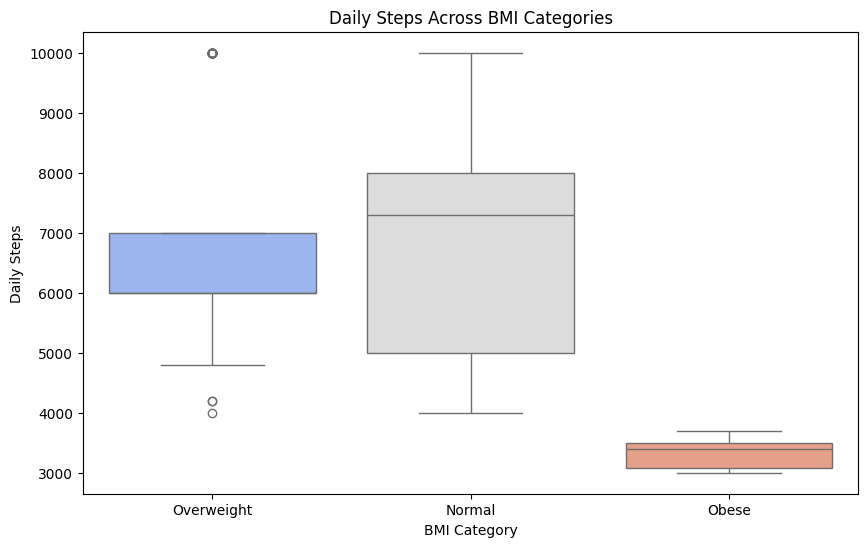

In [112]:
# Q: Does daily step count vary significantly across BMI categories?
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="BMI Category", y="Daily Steps", palette="coolwarm")
plt.title("Daily Steps Across BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Daily Steps")
plt.show()

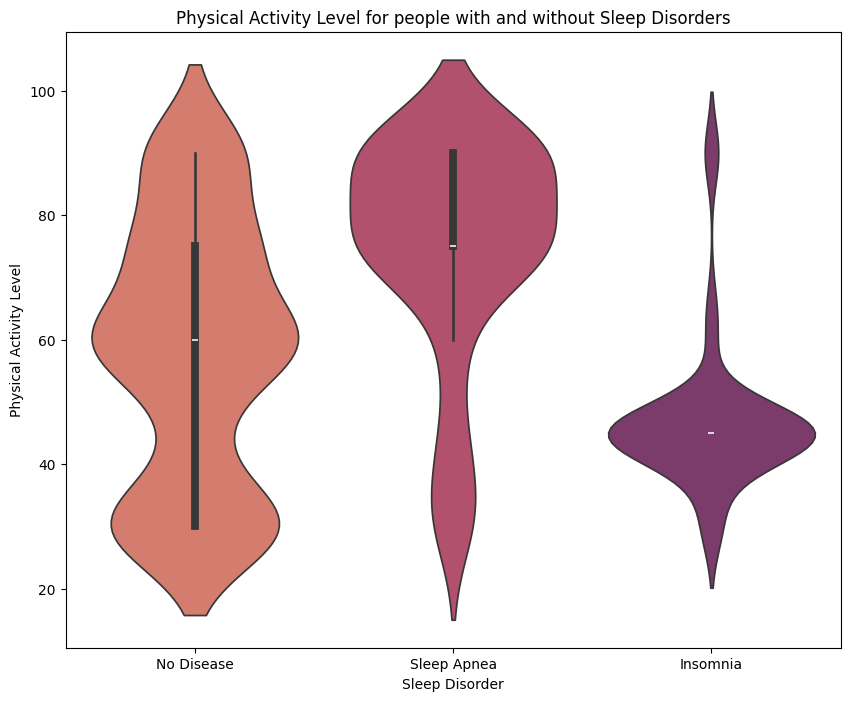

In [113]:
# Q: Does sleep disorder affect physical activity levels?
plt.figure(figsize=(10, 8))
sns.violinplot(data=df, x="Sleep Disorder", y="Physical Activity Level", palette="flare")
plt.title("Physical Activity Level for people with and without Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Physical Activity Level")
plt.show()

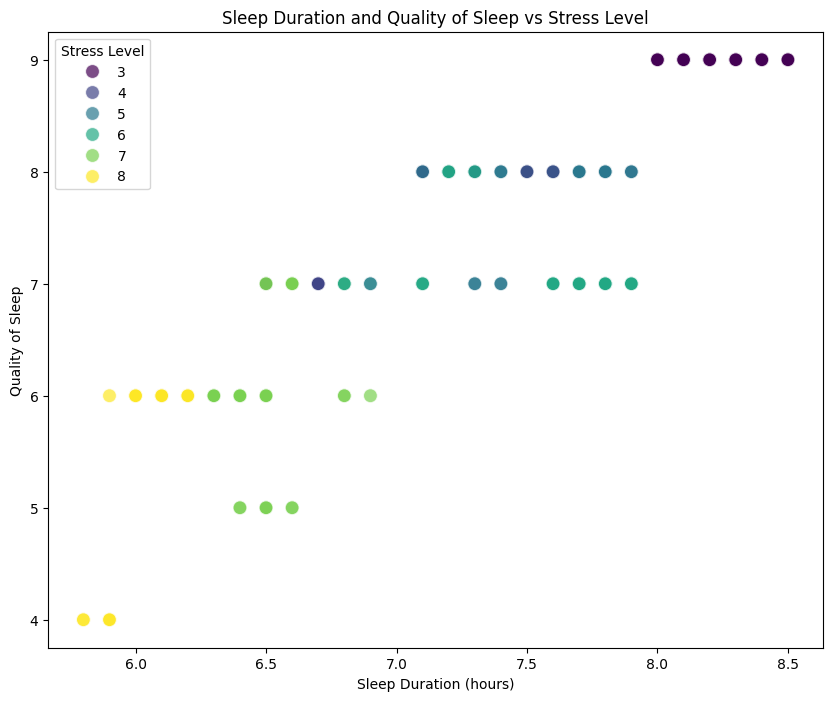

In [114]:
# Q: How do Sleep Duration and Quality of Sleep relate to Stress Levels?
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x="Sleep Duration", y="Quality of Sleep", hue="Stress Level", palette="viridis", s=100, alpha=0.7)
plt.title("Sleep Duration and Quality of Sleep vs Stress Level")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Quality of Sleep")
plt.legend(title="Stress Level")
plt.show()

In [115]:
# Q: How do Blood Pressure, Heart Rate, and Daily Steps vary across different levels of Sleep Quality?
# 'Blood Pressure' has already been processed into 'Systolic BP' and 'Diastolic BP' in an earlier step.
table = df.groupby('Quality of Sleep')[['Systolic BP', 'Heart Rate', 'Daily Steps']].mean()
table

,Systolic BP,Heart Rate,Daily Steps
Quality of Sleep,,,
4,136.400000,83.400000,3880.000000
5,130.571429,77.714286,4257.142857
6,131.047619,73.209524,7092.380952
7,127.701299,69.415584,6659.740260
8,124.091743,68.633028,7462.385321
9,131.887324,67.154930,6047.887324


In [116]:
# Q: How does Sleep Duration and Sleep Quality vary across different age groups?
# Define age groups
age_bins = [18, 30, 40, 50, 60]
age_labels = ['18-30', '31-40', '41-50', '51-60']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
avg_sleep = df.groupby('Age Group')[['Sleep Duration', 'Quality of Sleep']].mean().round(2)
print(avg_sleep)

# Drop 'Age Group' column after its use to avoid non-numeric data in ML features
df.drop(columns=['Age Group'], inplace=True)

           Sleep Duration  Quality of Sleep
Age Group                                  
18-30                6.47              5.79
31-40                7.07              7.23
41-50                6.91              6.97
51-60                7.63              8.17


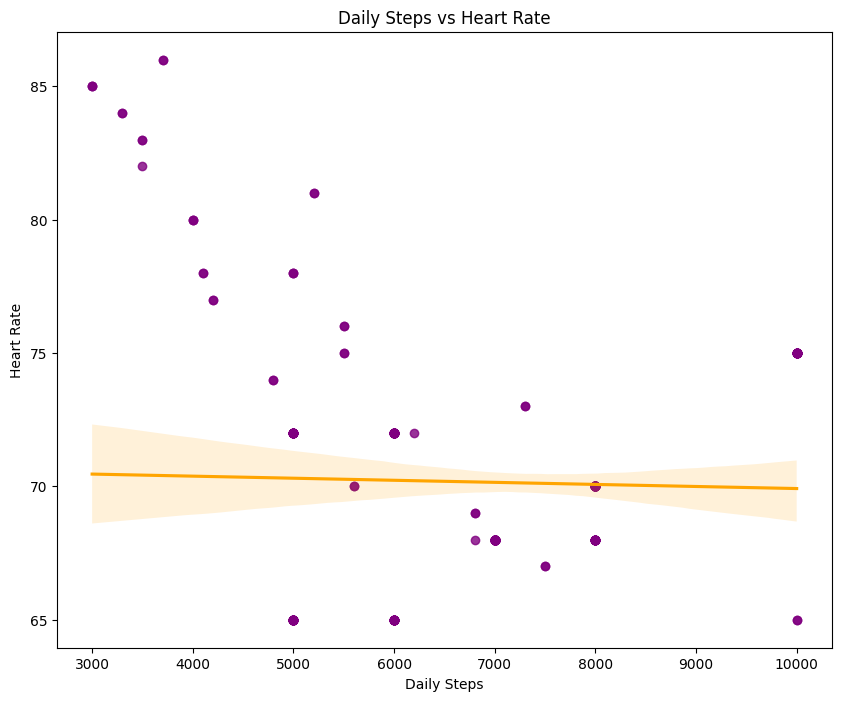

In [117]:
# Q: What is the relationship between daily steps and heart rate?
plt.figure(figsize=(10, 8))
sns.regplot(data=df, x="Daily Steps", y="Heart Rate", scatter_kws={"color": "purple"}, line_kws={"color": "orange"})
plt.title("Daily Steps vs Heart Rate")
plt.xlabel("Daily Steps")
plt.ylabel("Heart Rate")
plt.show()

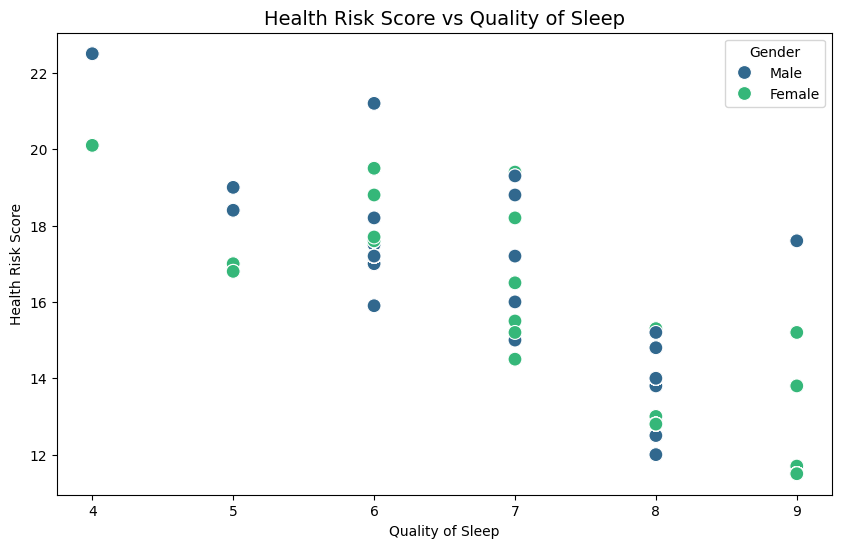

In [118]:
# Q: How does the Health Risk Score vary with Sleep Quality?
bmi_mapping = {'Normal': 1, 'Overweight': 2, 'Obese': 3}
df['BMI Score'] = df['BMI Category'].map(bmi_mapping)
# Calculate Health Risk Score (Health Risk Score=(BMI Score×2)+Stress Level+Heart Rate/10​)
df['Health Risk Score'] = (df['BMI Score'] * 2) + df['Stress Level'] + (df['Heart Rate'] / 10)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Quality of Sleep', y='Health Risk Score', hue='Gender', palette='viridis', s=100)
plt.title('Health Risk Score vs Quality of Sleep', fontsize=14)
plt.xlabel('Quality of Sleep')
plt.ylabel('Health Risk Score')
plt.legend(title='Gender')
plt.show()

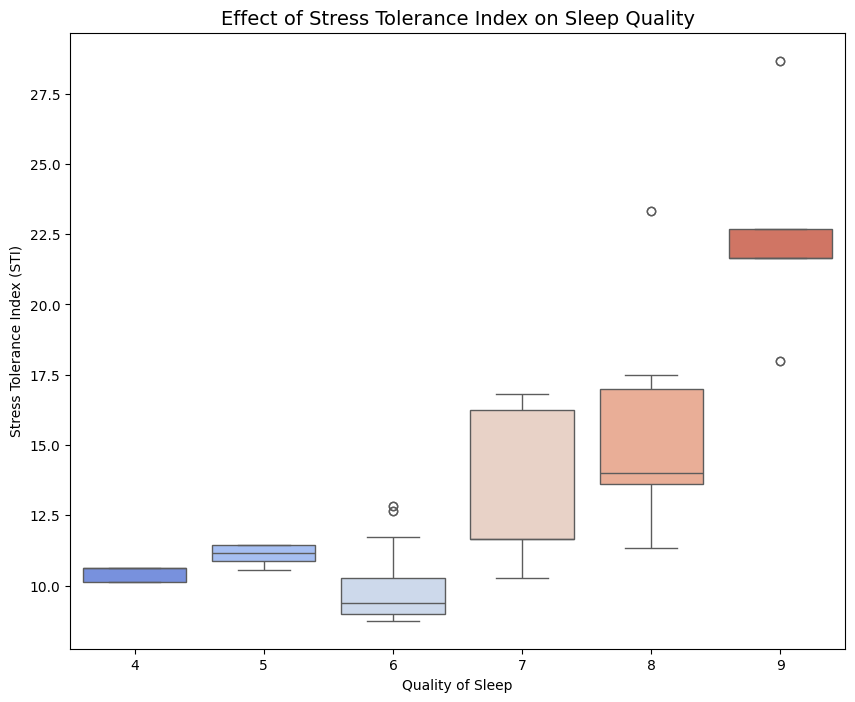

In [119]:
# Q: How does the Stress Tolerance Index (STI), calculated as the ratio of Heart Rate to Stress Level, impact the Quality of Sleep?
# Calculate Stress Tolerance Index
df['STI'] = df['Heart Rate'] / df['Stress Level']
plt.figure(figsize=(10, 8))
sns.boxplot(data=df, x='Quality of Sleep', y='STI', palette='coolwarm')
plt.title('Effect of Stress Tolerance Index on Sleep Quality', fontsize=14)
plt.xlabel('Quality of Sleep')
plt.ylabel('Stress Tolerance Index (STI)')
plt.show()

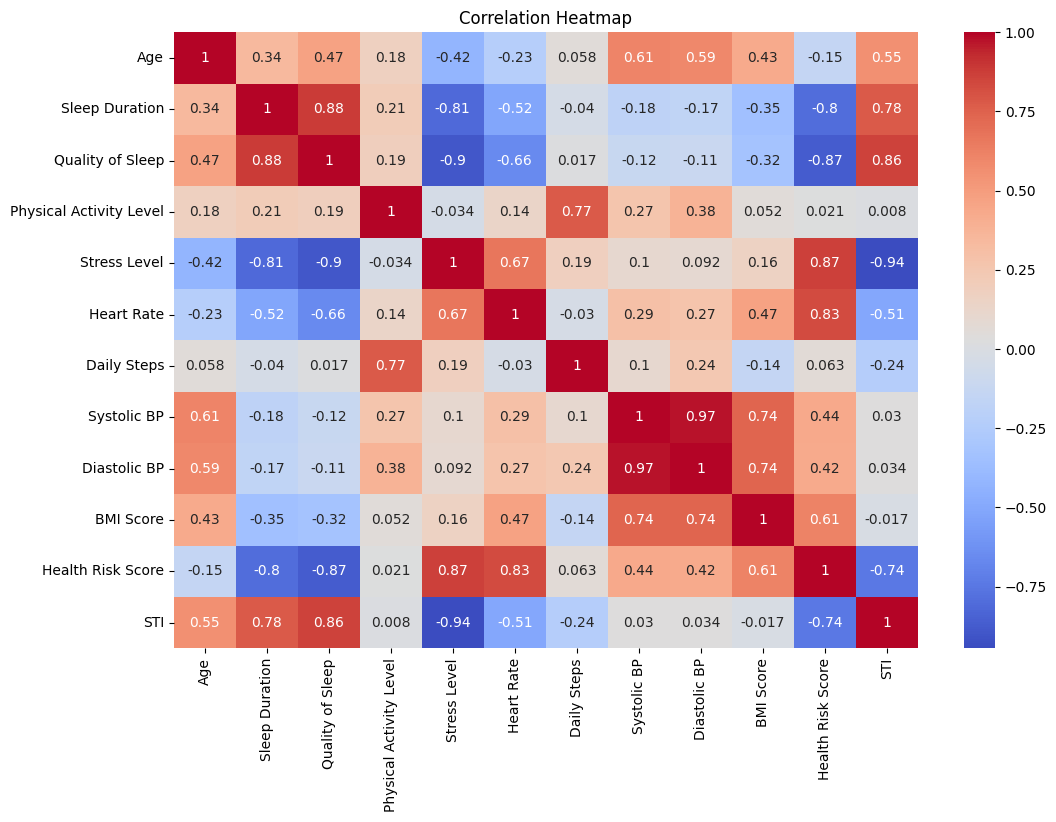

In [120]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Data Distribution

### Visualization of the distribution of data to identify potential outliers

<Figure size 640x480 with 0 Axes>

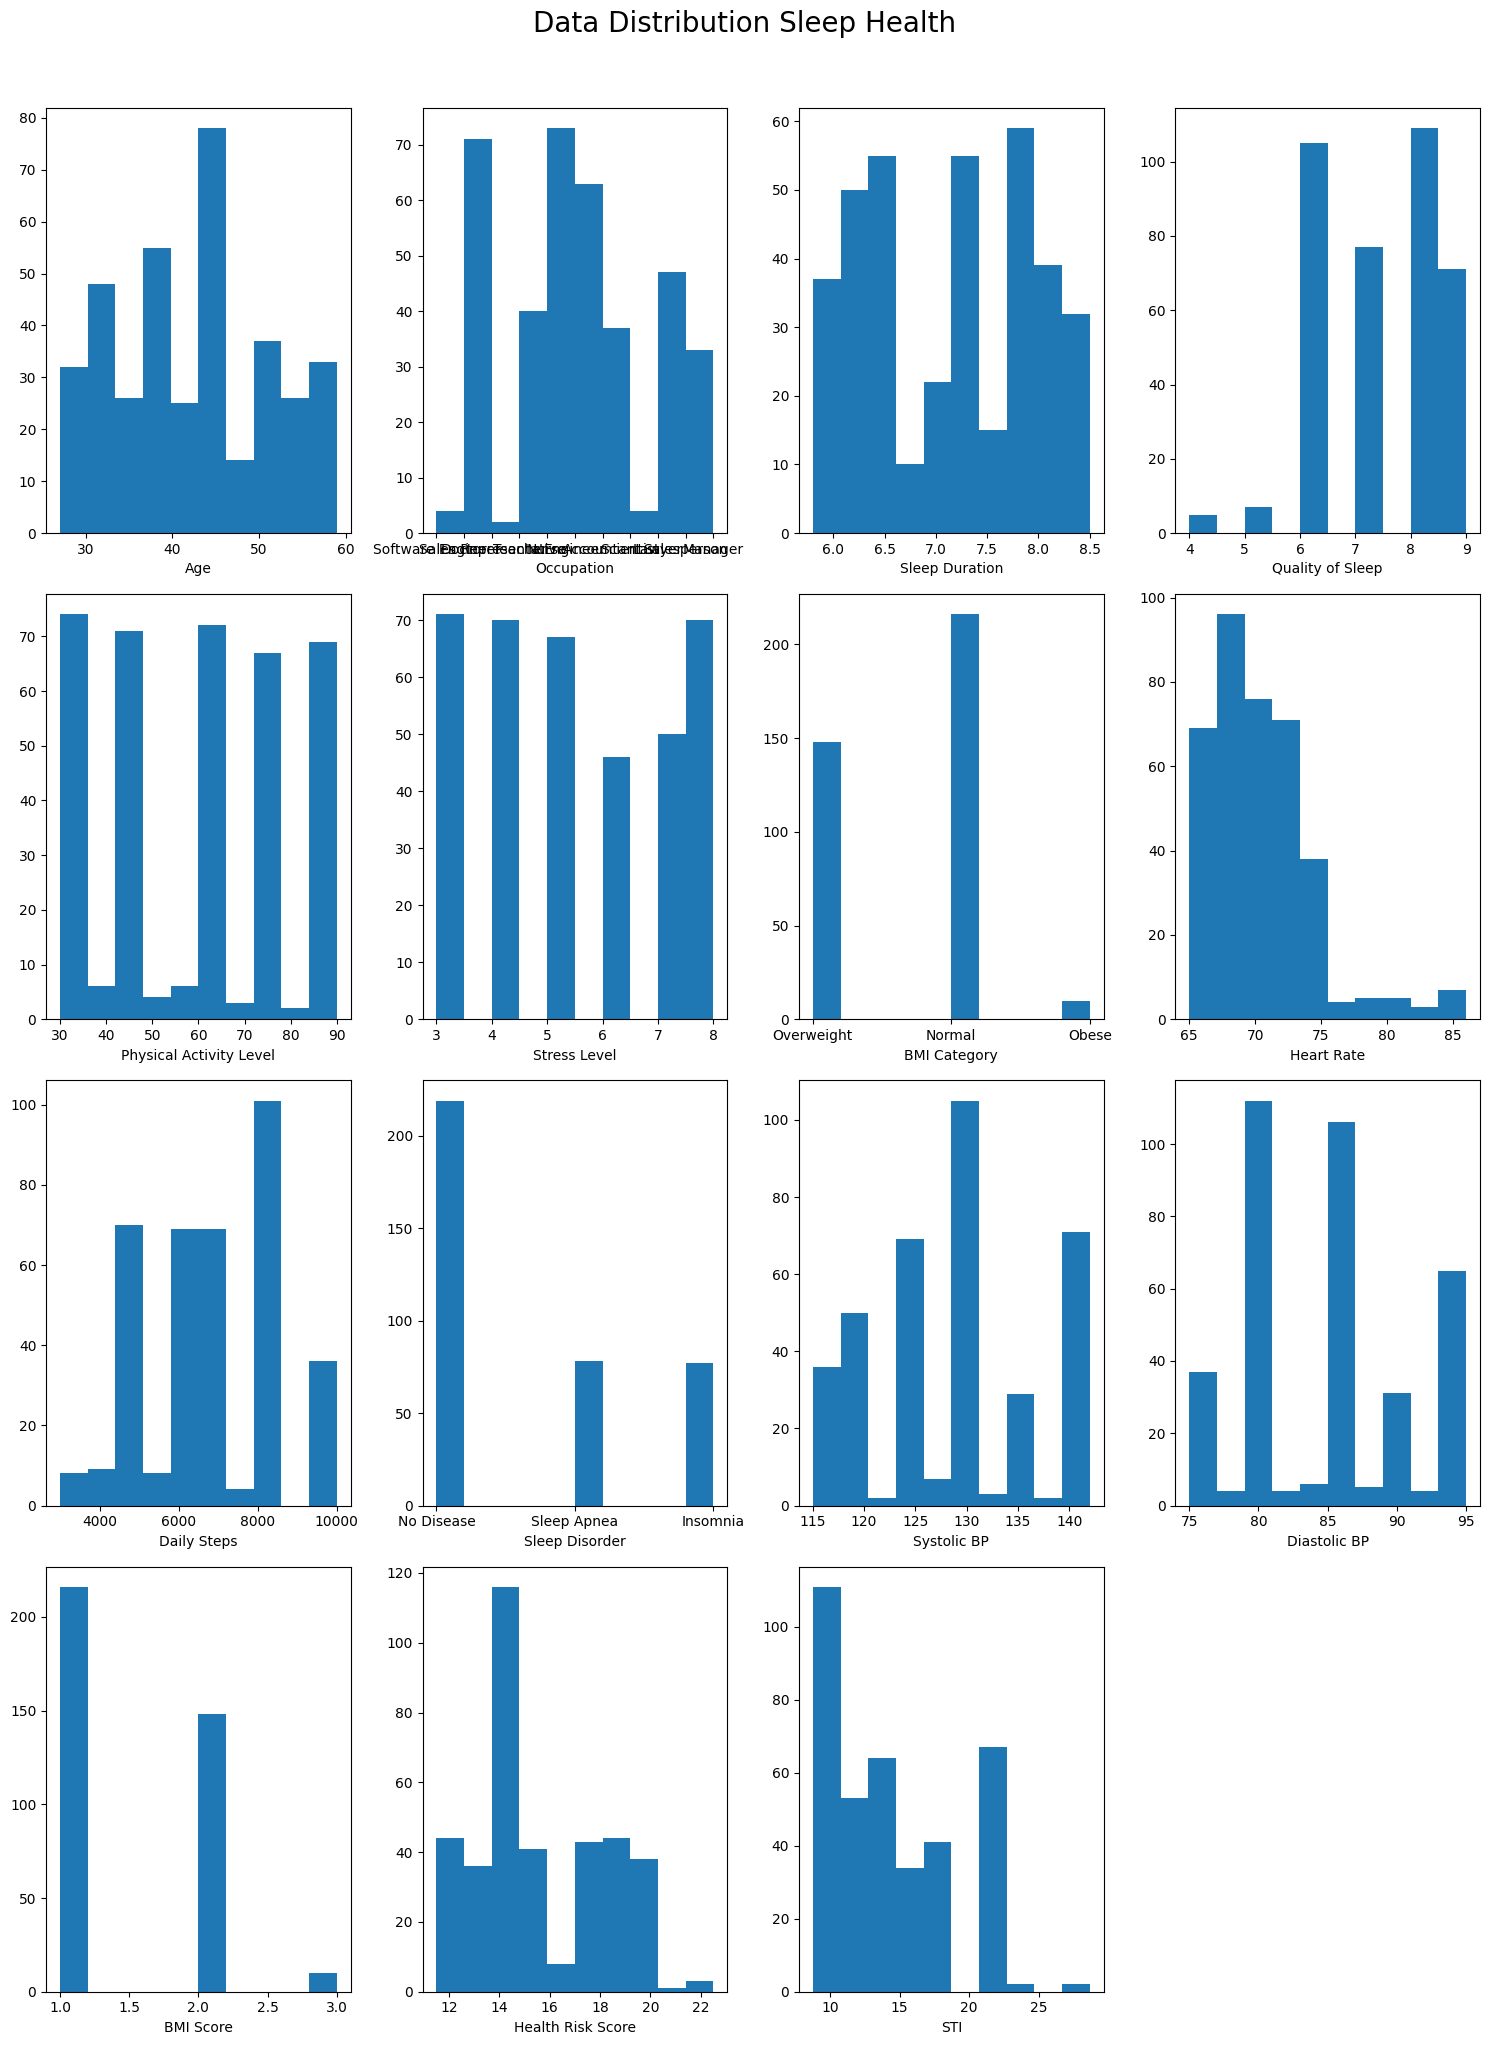

In [121]:
import math

plt.clf()

features_to_plot = df.columns[1:]
num_features = len(features_to_plot)

ncols = 4 # You can adjust the number of columns
nrows = math.ceil(num_features / ncols)

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

v, h = 0, 0
for feature in features_to_plot:
    if v < nrows:
        ax[v, h].hist(df[feature])
        ax[v, h].set_xlabel(feature)
        h+=1
        if h == ncols:
            h = 0
            v+=1

# Hide any unused subplots
for i in range(v * ncols + h, nrows * ncols):
    fig.delaxes(ax.flatten()[i])

plt.suptitle("Data Distribution Sleep Health", fontweight=300, fontsize=20, y=1.02)
fig.tight_layout()
plt.show()

Conclusion from these graphs:

- Nearly equal distributions of male and female participants
- Participants all younger than 60 years
- Low amount of participants reporting a sleep quality below 6
- Inbalance in BMI Category
- Daily Steps range up to 10.000 (potentially capped at this number)
- A big part of the participants suffer from sleep disorders (though below 50%)

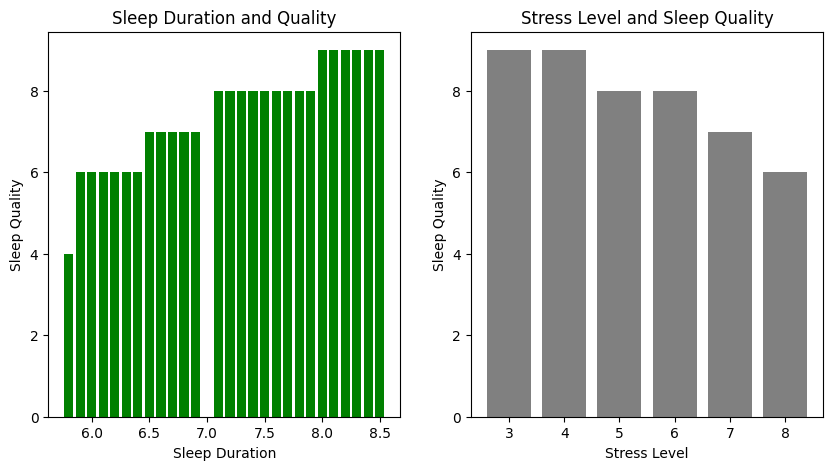

In [122]:
# Let's see if we can find some correlations here:
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].bar(df["Sleep Duration"], df["Quality of Sleep"], color="green", width=[0.08])
ax[0].set_xlabel("Sleep Duration"), ax[0].set_ylabel("Sleep Quality")
ax[0].set_title("Sleep Duration and Quality")

ax[1].bar(df["Stress Level"], df["Quality of Sleep"], color="grey")
ax[1].set_xlabel("Stress Level"), ax[1].set_ylabel("Sleep Quality")
ax[1].set_title("Stress Level and Sleep Quality");

# Machine learning

In [60]:
# Data cleaning for machine learning

In [123]:
# Change objects into categorical numbers
from sklearn import preprocessing

# Columns we want to transform
categorical = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]

label_encoder = preprocessing.LabelEncoder()

for label in categorical:
    df[label] = label_encoder.fit_transform(df[label])

df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,BMI Score,Health Risk Score,STI
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83,2,17.7,12.833333
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80,1,17.5,9.375000
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80,1,17.5,9.375000
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90,3,22.5,10.625000
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90,3,22.5,10.625000


In [124]:
# This cell's functionality has been addressed in previous steps and is no longer needed.
# The 'Blood Pressure' column parsing is now handled elsewhere.

In [125]:
# This cell's functionality (dropping 'Blood Pressure') has been moved to an earlier step.

In [126]:
# View our dataframe
df.head(5)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,BMI Score,Health Risk Score,STI
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83,2,17.7,12.833333
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80,1,17.5,9.375000
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80,1,17.5,9.375000
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90,3,22.5,10.625000
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90,3,22.5,10.625000


In [128]:
# Testing for duplicates excluding the ID column
columns = ['Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Systolic BP', 'Diastolic BP']

df.duplicated(subset=columns).value_counts()

,count
True,242
False,132


In [129]:
# Removing duplicates
duplicates = df.duplicated(subset=columns)

for i, value in enumerate(duplicates):
    if value==True:
        df.drop(index=i, inplace=True)

In [130]:
# Now we check again
df.duplicated(subset=columns).value_counts()

,count
False,132


In [131]:
# Imports from sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
# Models
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Ridge
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [132]:
# Split the data
# Explicitly select numerical columns for X to avoid non-numeric types
X = df[['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level',
        'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps',
        'Sleep Disorder', 'BMI Score', 'Health Risk Score', 'STI',
        'Systolic BP', 'Diastolic BP']]
y = df["Quality of Sleep"]

print("X columns and dtypes after cleaning:")
X.info()

X columns and dtypes after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 132 entries, 0 to 366
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   132 non-null    int64  
 1   Age                      132 non-null    int64  
 2   Occupation               132 non-null    int64  
 3   Sleep Duration           132 non-null    float64
 4   Physical Activity Level  132 non-null    int64  
 5   Stress Level             132 non-null    int64  
 6   BMI Category             132 non-null    int64  
 7   Heart Rate               132 non-null    int64  
 8   Daily Steps              132 non-null    int64  
 9   Sleep Disorder           132 non-null    int64  
 10  BMI Score                132 non-null    int64  
 11  Health Risk Score        132 non-null    float64
 12  STI                      132 non-null    float64
 13  Systolic BP              132 non-null    int64  

In [133]:
# Split into train and test sets
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [134]:
# Create a dictionary of our models
models = {"Ridge": Ridge(),
          "Linear Regression": LinearRegression(),
         "SVR": svm.SVR(),
         "RandomForest": RandomForestRegressor()}

In [135]:
# Fit all our models
np.random.seed(42)

for name, model in models.items():
    model.fit(X_train, y_train)

In [136]:
# Function to evaluate our models on different metrics
def model_scoring(name, model, X_test, y_test, collection):
    y_preds = model.predict(X_test)
    scores = {"R2": r2_score(y_test, y_preds),
           "MAE": mean_absolute_error(y_test, y_preds),
           "MSE": mean_squared_error(y_test, y_preds)}
    collection[name] = tuple(scores.values())
    print(name, scores)

In [137]:
# Function to evaluate all models
def models_evaluate(models, X_test, y_test):
    collection = {}
    for name, model in models.items():
        model_scoring(name, model, X_test, y_test, collection)
    return collection

In [138]:
# Save the evaluations to a variable
results = models_evaluate(models, X_test, y_test)

Ridge {'R2': 0.9274506722331948, 'MAE': 0.23366708580888498, 'MSE': 0.10927182700679301}
Linear Regression {'R2': 0.9281173721286035, 'MAE': 0.23259086581203156, 'MSE': 0.10826766173222692}
SVR {'R2': 0.21377230652154644, 'MAE': 0.9039467721295983, 'MSE': 1.1841947975848313}
RandomForest {'R2': 0.9302524590163934, 'MAE': 0.09259259259259246, 'MSE': 0.1050518518518518}


In [139]:
# Create a tuple of our scoring methods
scorer = ("R2", "MAE", "MSE")

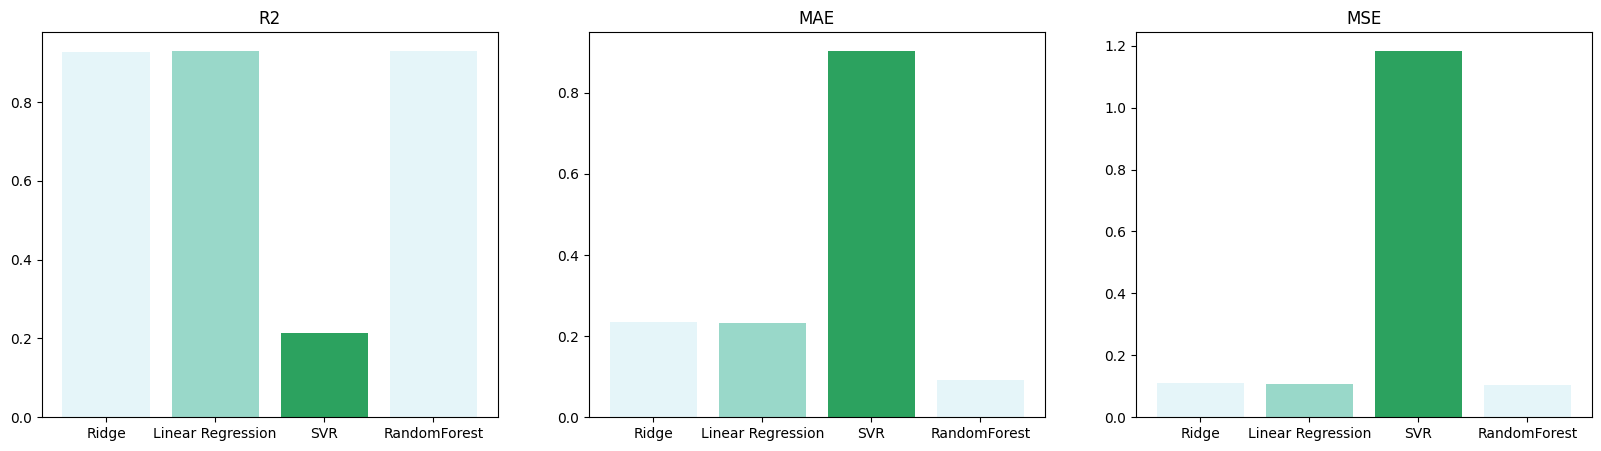

In [140]:
# Creating subplots for each evaluation method
fig, ax = plt.subplots(ncols=3, figsize=(20, 5))
for i, ev in enumerate(scorer):
    values = []
    for scores in results.values():
        values.append(scores[i])
    ax[i].bar(results.keys(), values, color=["#e5f5f9", "#99d8c9", "#2ca25f"])
    ax[i].set_title(scorer[i])

In [141]:
# Parameter grids for Ridge and RandomForest hyperparameter tuning
grid_ridge = {"alpha": np.arange(0.1, 2, 0.1)}

grid_rf = {"n_estimators": np.arange(100, 2000, 20),
          "max_features": ["auto", "sqrt"],
          "max_depth": np.arange(10, 110, 11),
          "min_samples_split": [2, 5, 10],
          "min_samples_leaf": [1, 2, 4],
          "bootstrap": [True, False]}

In [142]:
# RandomizedSearchCV for the best parameters of Ridge
rs_ridge = RandomizedSearchCV(Ridge(),
                             param_distributions=grid_ridge,
                             n_iter=20,
                             cv=5,
                             random_state=42)
rs_ridge.fit(X_train, y_train);

In [143]:
# The same for our RandomForestRegressor
rs_rf = RandomizedSearchCV(RandomForestRegressor(),
                          param_distributions=grid_rf,
                          n_iter=20,
                          cv=5,
                          random_state=42)
rs_rf.fit(X_train, y_train);

In [144]:
# Create dictionary for our selected models and evaluate them with our function
refined_models = {"Ridge": rs_ridge,
                 "RandomForest": rs_rf}

rs_results = models_evaluate(refined_models, X_test, y_test)

Ridge {'R2': 0.9268670296528099, 'MAE': 0.23405905465875604, 'MSE': 0.110150893609348}
RandomForest {'R2': 0.9437154266163433, 'MAE': 0.06868386243386235, 'MSE': 0.08477429571365577}


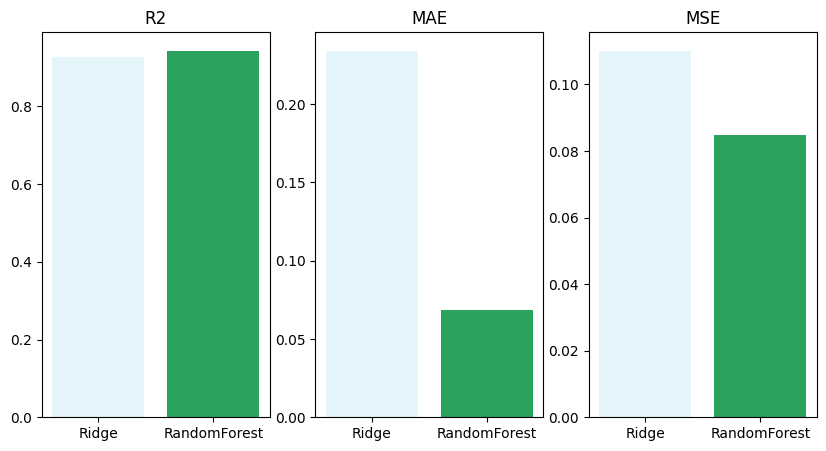

In [145]:
# Plot the results from our tuned models
fig, ax = plt.subplots(ncols=3, figsize=(10, 5))
for i, ev in enumerate(scorer):
    values = []
    for scores in rs_results.values():
        values.append(scores[i])
    ax[i].bar(rs_results.keys(), values, color=["#e5f5f9", "#2ca25f"])
    ax[i].set_title(scorer[i])

As we can see, our RandomForestRegressor outperforms the RidgeRegressor on R^2, as well as shows lower error scores. So our preferred model can predict the sleep quality with a 96.78% accuracy.

The only thing that is now left to do, is to check the feature importances.

In [146]:
# View the best parameters
rs_rf.best_params_

{'n_estimators': np.int64(280),
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': np.int64(21),
 'bootstrap': False}

In [147]:
# Instantiate the ideal model
ideal_model = RandomForestRegressor(n_estimators=780,
                                    min_samples_split=2,
                                    min_samples_leaf=2,
                                    max_features="sqrt",
                                    max_depth=43,
                                    bootstrap=False)
ideal_model.fit(X_train, y_train);

In [148]:
importances = ideal_model.feature_importances_
importances

array([0.00329285, 0.06042044, 0.02364583, 0.22395942, 0.03498307,
       0.1699454 , 0.00594398, 0.08337855, 0.03124182, 0.00300864,
       0.00903874, 0.17603488, 0.14453225, 0.0124182 , 0.01815591])

In [149]:
# Create a dataframe with the importances
fi = pd.DataFrame({"features": X_train.columns,
                         "feature_importances": importances}).sort_values("feature_importances", ascending=False).reset_index(drop=True)
fi

,features,feature_importances
0,Sleep Duration,0.223959
1,Health Risk Score,0.176035
2,Stress Level,0.169945
3,STI,0.144532
4,Heart Rate,0.083379
5,Age,0.060420
6,Physical Activity Level,0.034983
7,Daily Steps,0.031242
8,Occupation,0.023646
9,Diastolic BP,0.018156


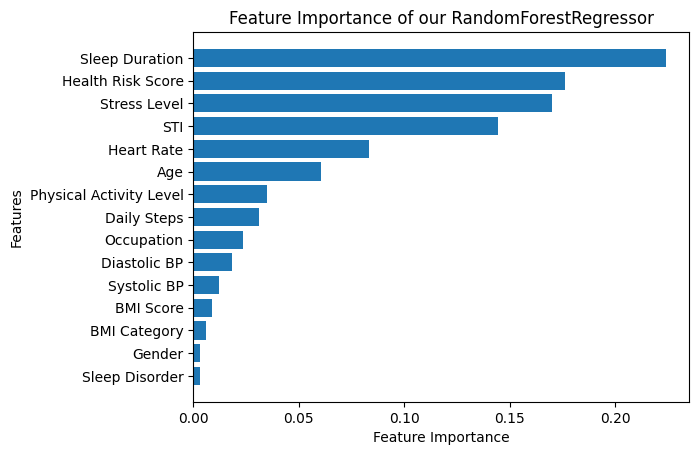

In [150]:
# Plot our feature importances
fig, ax = plt.subplots()
ax.barh(fi["features"], fi["feature_importances"])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importance of our RandomForestRegressor")
ax.invert_yaxis()